# 04 — EDA: theLook eCommerce

Deep-dive into customer behaviour, revenue patterns, and traffic source efficiency from the theLook public dataset.

**Input**: `data/staging/thelook_users_clean.parquet`, `data/mart/thelook_performance.parquet`

Sections:
1. Setup & load data
2. Top-line summary
3. Revenue & LTV distribution
4. Traffic source analysis (conversion, revenue, CAC/ROAS)
5. Behavioral funnel (events → cart → purchase)
6. Demographics (age, gender)
7. Cohort retention
8. Time trends
9. Key findings

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
STAGING_DIR = PROJECT_ROOT / "data" / "staging"
MART_DIR = PROJECT_ROOT / "data" / "mart"

# Dark theme (same as notebook 03)
plt.rcParams.update({
    "figure.facecolor": "#0f0f0f",
    "axes.facecolor": "#0f0f0f",
    "axes.edgecolor": "#333333",
    "axes.labelcolor": "#cccccc",
    "text.color": "#cccccc",
    "xtick.color": "#999999",
    "ytick.color": "#999999",
    "grid.color": "#222222",
    "legend.facecolor": "#1a1a1a",
    "legend.edgecolor": "#333333",
    "figure.dpi": 120,
})

GREEN = "#00c896"
RED = "#ff4d6d"
BLUE = "#4e9af1"
AMBER = "#f0a500"
GREY = "#888888"
PURPLE = "#b57aff"

In [2]:
users = pd.read_parquet(STAGING_DIR / "thelook_users_clean.parquet")
mart = pd.read_parquet(MART_DIR / "thelook_performance.parquet")

print(f"Users: {users.shape[0]:,} rows × {users.shape[1]} cols")
print(f"Mart:  {mart.shape[0]:,} rows × {mart.shape[1]} cols")
users.head(3)

Users: 100,000 rows × 28 cols
Mart:  435 rows × 13 cols


,user_id,age,gender,country,city,traffic_source,user_created_at,total_orders,completed_orders,cancelled_orders,...,purchase_events,cart_events,product_views,first_event,last_event,converted,high_value,days_to_first_order,avg_order_value,user_month
0,10479,63,M,Brasil,null,Search,2026-02-14 08:23:00+00:00,2.0,1.0,0.0,...,2,2,2,2026-02-14 13:10:54+00:00,2026-02-21 06:17:23+00:00,1,0,0.3,25.0,2026-02-01
1,82675,56,F,Brasil,null,Search,2022-04-18 02:47:00+00:00,1.0,0.0,0.0,...,2,4,4,2025-04-23 06:33:39+00:00,2025-04-26 07:30:11+00:00,0,0,1101.3,NaN,2022-04-01
2,41297,49,F,Brasil,null,Search,2020-08-25 00:19:00+00:00,1.0,0.0,0.0,...,2,4,4,2025-04-21 04:34:23+00:00,2025-04-25 04:43:32+00:00,0,0,1700.3,NaN,2020-08-01


---
## 2. Top-Line Summary

In [3]:
total_users = len(users)
total_converted = users["converted"].sum()
total_high_value = users["high_value"].sum()
total_revenue = users["total_revenue"].sum()
conv_rate = total_converted / total_users
avg_rev_per_user = total_revenue / total_users
avg_rev_converted = total_revenue / total_converted if total_converted > 0 else 0

print("=" * 50)
print("  theLook — COMMERCIAL SUMMARY")
print("=" * 50)
print(f"  Total users:          {total_users:,}")
print(f"  Converted (purchased):{total_converted:,}  ({conv_rate:.1%})")
print(f"  High-value users:     {total_high_value:,}")
print(f"  ---")
print(f"  Total revenue:        ${total_revenue:,.0f}")
print(f"  Rev / user (all):     ${avg_rev_per_user:.2f}")
print(f"  Rev / user (buyers):  ${avg_rev_converted:.2f}")
print("=" * 50)

  theLook — COMMERCIAL SUMMARY
  Total users:          100,000
  Converted (purchased):27,586  (27.6%)
  High-value users:     5,519
  ---
  Total revenue:        $2,695,974
  Rev / user (all):     $26.96
  Rev / user (buyers):  $97.73


---
## 3. Revenue & LTV Distribution

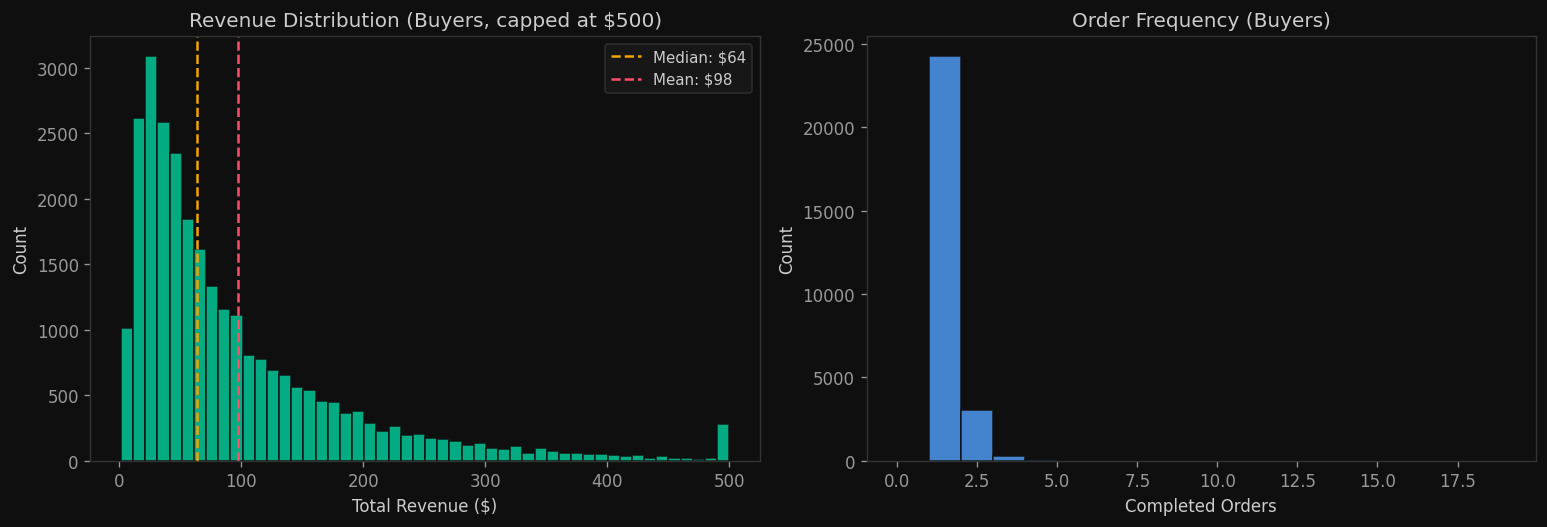

Revenue percentiles: P25=$32, P50=$64, P75=$128, P95=$293


In [4]:
buyers = users[users["converted"] == 1].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Revenue histogram (capped at 500 for readability)
rev_capped = buyers["total_revenue"].clip(upper=500)
axes[0].hist(rev_capped, bins=50, color=GREEN, edgecolor="#0f0f0f", alpha=0.85)
axes[0].axvline(buyers["total_revenue"].median(), color=AMBER, ls="--",
                label=f'Median: ${buyers["total_revenue"].median():,.0f}')
axes[0].axvline(buyers["total_revenue"].mean(), color=RED, ls="--",
                label=f'Mean: ${buyers["total_revenue"].mean():,.0f}')
axes[0].set_xlabel("Total Revenue ($)")
axes[0].set_ylabel("Count")
axes[0].set_title("Revenue Distribution (Buyers, capped at $500)")
axes[0].legend(fontsize=9)

# Order count distribution
axes[1].hist(buyers["completed_orders"], bins=range(0, 20), color=BLUE,
             edgecolor="#0f0f0f", alpha=0.85)
axes[1].set_xlabel("Completed Orders")
axes[1].set_ylabel("Count")
axes[1].set_title("Order Frequency (Buyers)")

plt.tight_layout()
plt.show()

print(f"Revenue percentiles: "
      f"P25=${buyers['total_revenue'].quantile(0.25):,.0f}, "
      f"P50=${buyers['total_revenue'].quantile(0.50):,.0f}, "
      f"P75=${buyers['total_revenue'].quantile(0.75):,.0f}, "
      f"P95=${buyers['total_revenue'].quantile(0.95):,.0f}")

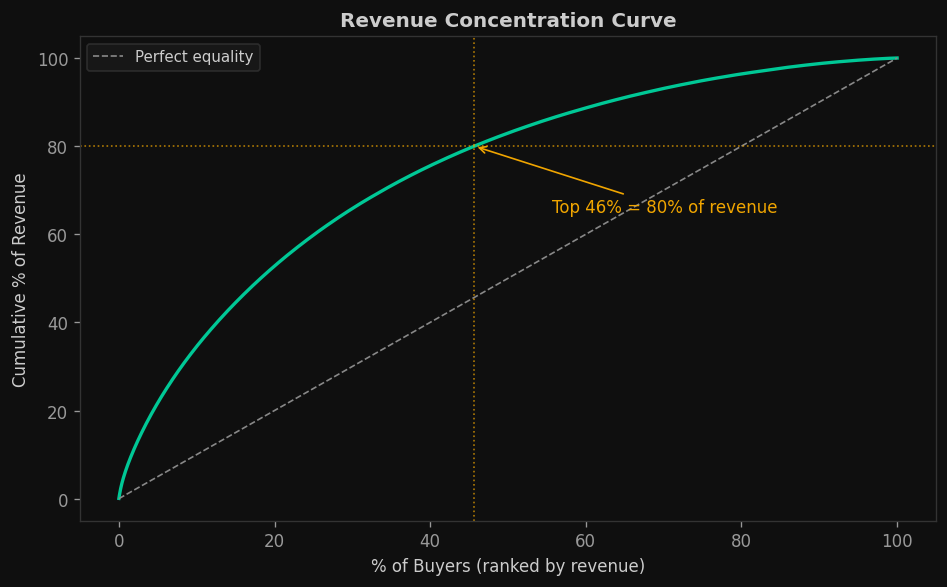

In [5]:
# Revenue concentration — what % of buyers drive what % of revenue?
buyers_sorted = buyers.sort_values("total_revenue", ascending=False)
buyers_sorted["cumulative_rev"] = buyers_sorted["total_revenue"].cumsum()
buyers_sorted["cumulative_pct"] = buyers_sorted["cumulative_rev"] / total_revenue * 100
buyers_sorted["buyer_rank_pct"] = np.arange(1, len(buyers_sorted) + 1) / len(buyers_sorted) * 100

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(buyers_sorted["buyer_rank_pct"], buyers_sorted["cumulative_pct"],
        color=GREEN, lw=2)
ax.plot([0, 100], [0, 100], color=GREY, ls="--", lw=1, label="Perfect equality")
ax.axhline(80, color=AMBER, ls=":", lw=1, alpha=0.7)

# Find where top N% = 80% revenue
pct_80 = buyers_sorted[buyers_sorted["cumulative_pct"] >= 80]["buyer_rank_pct"].min()
ax.axvline(pct_80, color=AMBER, ls=":", lw=1, alpha=0.7)
ax.annotate(f"Top {pct_80:.0f}% = 80% of revenue",
            xy=(pct_80, 80), xytext=(pct_80 + 10, 65),
            arrowprops=dict(arrowstyle="->", color=AMBER), color=AMBER, fontsize=10)

ax.set_xlabel("% of Buyers (ranked by revenue)")
ax.set_ylabel("Cumulative % of Revenue")
ax.set_title("Revenue Concentration Curve", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## 4. Traffic Source Analysis

Which channels bring the highest-value users?

In [6]:
# Traffic source summary
ts = (
    users.groupby("traffic_source")
    .agg(
        users=("user_id", "count"),
        buyers=("converted", "sum"),
        revenue=("total_revenue", "sum"),
        high_value=("high_value", "sum"),
        avg_orders=("total_orders", "mean"),
    )
)
ts["conv_%"] = (ts["buyers"] / ts["users"] * 100).round(1)
ts["rev_per_user"] = (ts["revenue"] / ts["users"]).round(2)
ts["rev_per_buyer"] = (ts["revenue"] / ts["buyers"].replace(0, np.nan)).round(2)
ts["hv_%"] = (ts["high_value"] / ts["buyers"].replace(0, np.nan) * 100).round(1)
ts = ts.sort_values("rev_per_user", ascending=False)

print(ts[["users", "buyers", "conv_%", "rev_per_user", "rev_per_buyer", "hv_%", "avg_orders"]].to_string())

                users  buyers  conv_%  rev_per_user  rev_per_buyer  hv_%  avg_orders
traffic_source                                                                      
Email            4914    1331    27.1         27.97         103.27  21.1    1.254782
Facebook         6047    1610    26.6         27.33         102.65  22.0    1.251034
Organic         14970    4097    27.4         27.08          98.94  21.0    1.255110
Search          70135   19456    27.7         26.87          96.88  19.6    1.247751
Display          3934    1092    27.8         26.19          94.37  18.3    1.238434


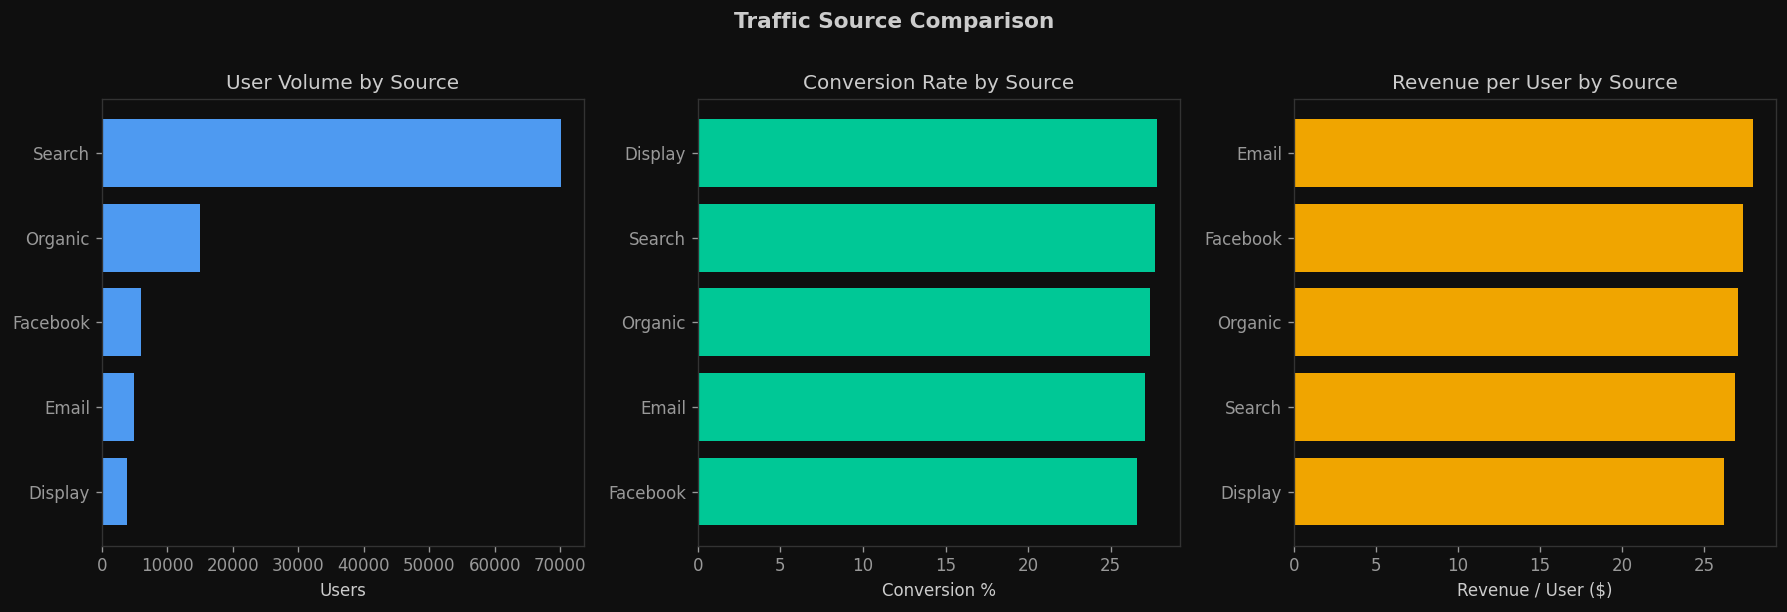

In [7]:
# Visual — conversion rate and rev/user by traffic source
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# User volume
ts_sorted = ts.sort_values("users", ascending=True)
axes[0].barh(ts_sorted.index, ts_sorted["users"], color=BLUE)
axes[0].set_xlabel("Users")
axes[0].set_title("User Volume by Source")

# Conversion rate
ts_sorted = ts.sort_values("conv_%", ascending=True)
axes[1].barh(ts_sorted.index, ts_sorted["conv_%"], color=GREEN)
axes[1].set_xlabel("Conversion %")
axes[1].set_title("Conversion Rate by Source")

# Revenue per user
ts_sorted = ts.sort_values("rev_per_user", ascending=True)
axes[2].barh(ts_sorted.index, ts_sorted["rev_per_user"], color=AMBER)
axes[2].set_xlabel("Revenue / User ($)")
axes[2].set_title("Revenue per User by Source")

plt.suptitle("Traffic Source Comparison", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

Traffic Source — Spend Efficiency (from mart)
                    spend  conversions       revenue     cac    cpl  roas
traffic_source                                                           
Search          360483.70        19456  1.884855e+06   18.53   5.14  5.23
Email            35997.84         1331  1.374573e+05   27.05   7.33  3.82
Facebook        232218.38         1610  1.652697e+05  144.24   38.4  0.71
Display         181185.00         1092  1.030508e+05  165.92  46.06  0.57
Organic              0.00         4097  4.053410e+05    0.00    0.0   NaN


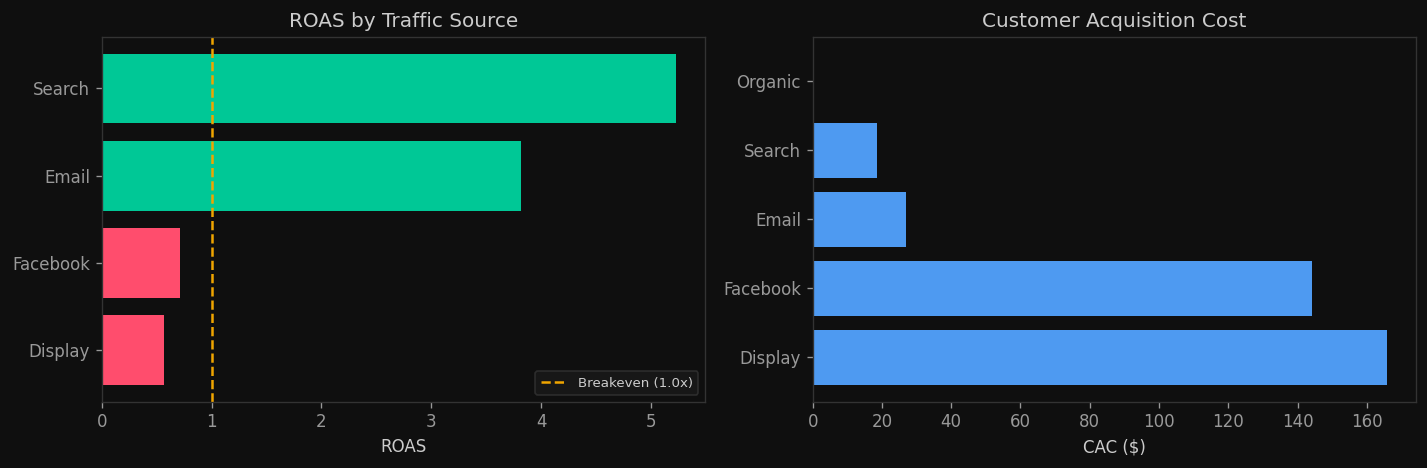

In [8]:
# CAC and ROAS from mart table
mart_totals = (
    mart.groupby("traffic_source")
    .agg(
        spend=("spend", "sum"),
        users=("total_users", "sum"),
        conversions=("conversions", "sum"),
        revenue=("total_revenue", "sum"),
    )
)
mart_totals["cac"] = (mart_totals["spend"] / mart_totals["conversions"].replace(0, np.nan)).round(2)
mart_totals["roas"] = (mart_totals["revenue"] / mart_totals["spend"].replace(0, np.nan)).round(2)
mart_totals["cpl"] = (mart_totals["spend"] / mart_totals["users"].replace(0, np.nan)).round(2)
mart_totals = mart_totals.sort_values("roas", ascending=False)

print("Traffic Source — Spend Efficiency (from mart)")
print(mart_totals[["spend", "conversions", "revenue", "cac", "cpl", "roas"]].to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ROAS
roas_sorted = mart_totals.sort_values("roas", ascending=True)
colors_roas = [GREEN if v >= 1.0 else RED for v in roas_sorted["roas"]]
axes[0].barh(roas_sorted.index, roas_sorted["roas"], color=colors_roas)
axes[0].axvline(1.0, color=AMBER, ls="--", label="Breakeven (1.0x)")
axes[0].set_xlabel("ROAS")
axes[0].set_title("ROAS by Traffic Source")
axes[0].legend(fontsize=8)

# CAC
cac_sorted = mart_totals.sort_values("cac", ascending=False)
axes[1].barh(cac_sorted.index, cac_sorted["cac"], color=BLUE)
axes[1].set_xlabel("CAC ($)")
axes[1].set_title("Customer Acquisition Cost")

plt.tight_layout()
plt.show()

---
## 5. Behavioral Funnel

How do users move from browsing → cart → purchase?

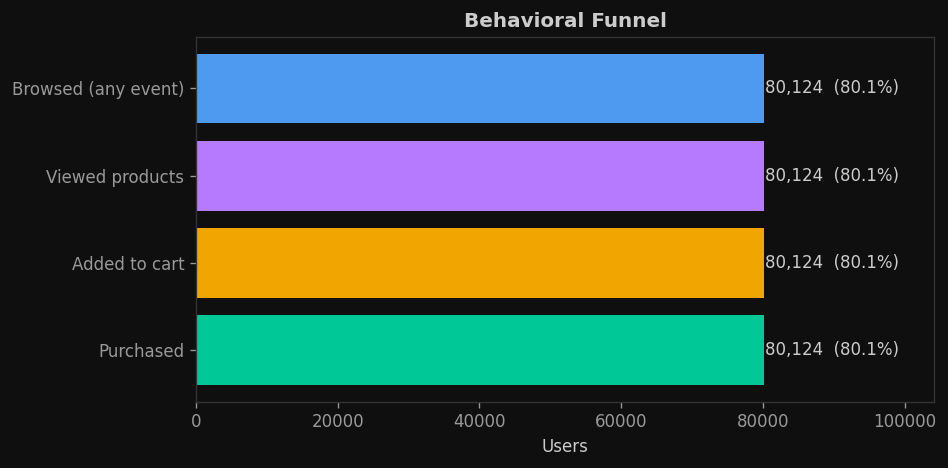

  Browsed (any event) → Viewed products: 100.0%
  Viewed products → Added to cart: 100.0%
  Added to cart → Purchased: 100.0%


In [9]:
# Event funnel — users who had each event type
users_with_events = users[users["total_events"] > 0].copy()
n_events_users = len(users_with_events)

funnel_data = {
    "Browsed (any event)": n_events_users,
    "Viewed products": (users["product_views"] > 0).sum(),
    "Added to cart": (users["cart_events"] > 0).sum(),
    "Purchased": (users["purchase_events"] > 0).sum(),
}
funnel = pd.Series(funnel_data)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(funnel.index, funnel.values,
               color=[BLUE, PURPLE, AMBER, GREEN])

for bar, val in zip(bars, funnel.values):
    pct = val / total_users * 100
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height() / 2,
            f"{val:,}  ({pct:.1f}%)", va="center", fontsize=10, color="#cccccc")

ax.set_xlabel("Users")
ax.set_title("Behavioral Funnel", fontsize=12, fontweight="bold")
ax.invert_yaxis()
ax.set_xlim(0, funnel.max() * 1.3)
plt.tight_layout()
plt.show()

# Step-to-step conversion rates
steps = list(funnel_data.keys())
for i in range(1, len(steps)):
    prev, curr = funnel[steps[i - 1]], funnel[steps[i]]
    print(f"  {steps[i-1]} → {steps[i]}: {curr / prev:.1%}")

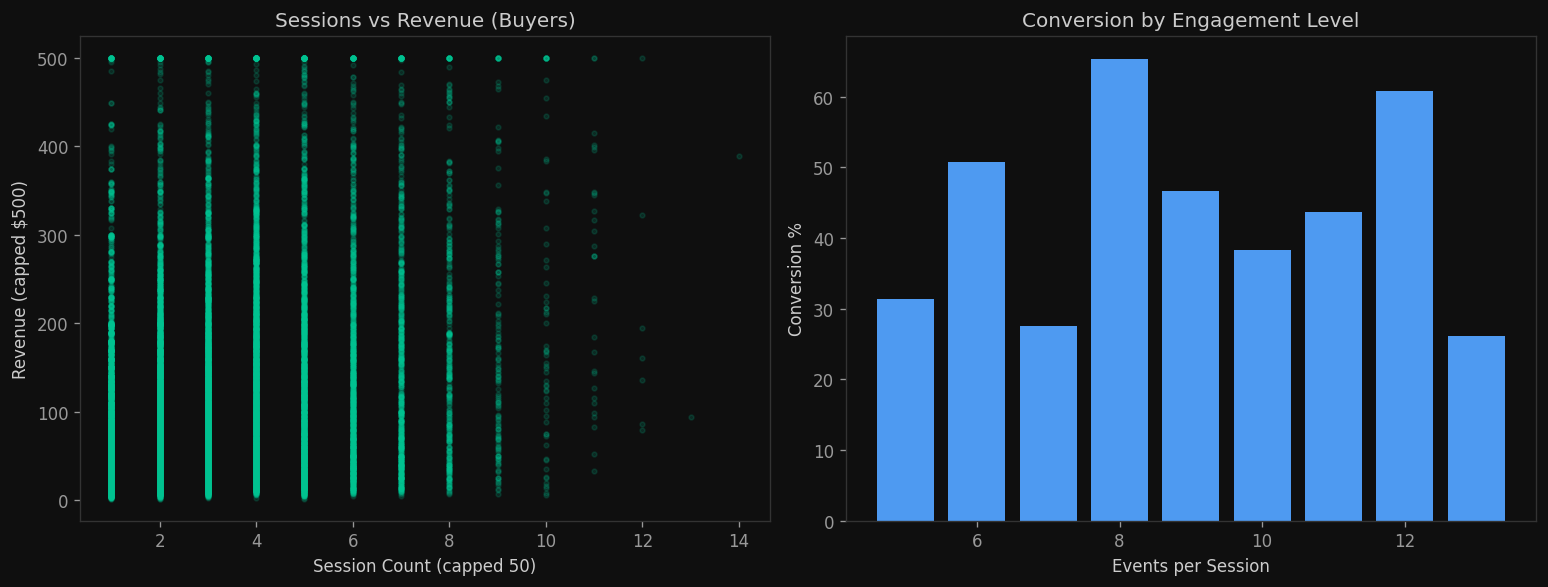

In [10]:
# Session engagement vs revenue
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Sessions vs revenue (buyers only)
buyer_events = buyers[buyers["session_count"] > 0].copy()
sessions_capped = buyer_events["session_count"].clip(upper=50)

axes[0].scatter(sessions_capped, buyer_events["total_revenue"].clip(upper=500),
                alpha=0.15, s=8, color=GREEN)
axes[0].set_xlabel("Session Count (capped 50)")
axes[0].set_ylabel("Revenue (capped $500)")
axes[0].set_title("Sessions vs Revenue (Buyers)")

# Events per session → conversion binned
users_with_sessions = users[users["session_count"] > 0].copy()
users_with_sessions["events_per_session"] = (
    users_with_sessions["total_events"] / users_with_sessions["session_count"]
).round(0)

eps_conv = (
    users_with_sessions.groupby("events_per_session")
    .agg(n=("user_id", "count"), conv=("converted", "sum"))
)
eps_conv = eps_conv[eps_conv["n"] >= 50]  # min sample size
eps_conv["conv_%"] = (eps_conv["conv"] / eps_conv["n"] * 100).round(1)

axes[1].bar(eps_conv.index, eps_conv["conv_%"], color=BLUE, width=0.8)
axes[1].set_xlabel("Events per Session")
axes[1].set_ylabel("Conversion %")
axes[1].set_title("Conversion by Engagement Level")

plt.tight_layout()
plt.show()

---
## 6. Demographics

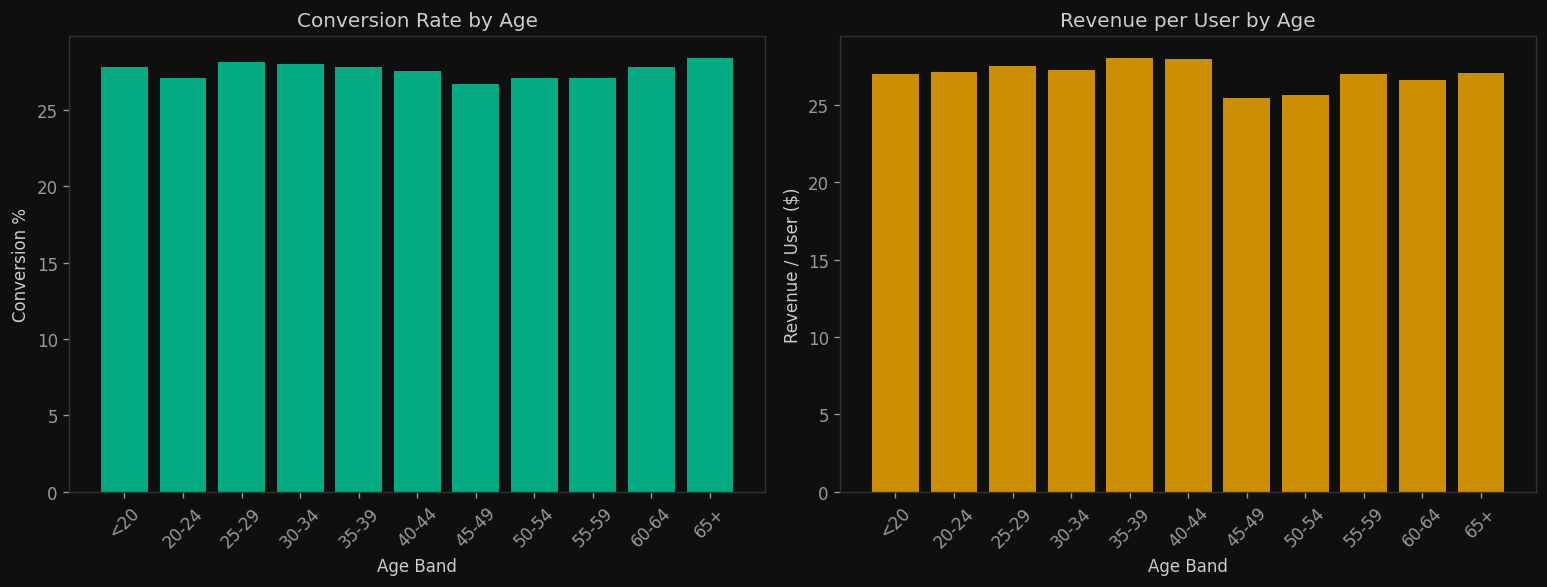

In [11]:
# Age — conversion and revenue
age_bins = [0, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 100]
age_labels = ["<20", "20-24", "25-29", "30-34", "35-39", "40-44", "45-49", "50-54", "55-59", "60-64", "65+"]
users["age_band"] = pd.cut(users["age"], bins=age_bins, labels=age_labels)

age_stats = (
    users.groupby("age_band", observed=True)
    .agg(users=("user_id", "count"), buyers=("converted", "sum"), revenue=("total_revenue", "sum"))
)
age_stats["conv_%"] = (age_stats["buyers"] / age_stats["users"] * 100).round(1)
age_stats["rev_per_user"] = (age_stats["revenue"] / age_stats["users"]).round(2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(age_stats.index.astype(str), age_stats["conv_%"], color=GREEN, alpha=0.85)
axes[0].set_xlabel("Age Band")
axes[0].set_ylabel("Conversion %")
axes[0].set_title("Conversion Rate by Age")

axes[1].bar(age_stats.index.astype(str), age_stats["rev_per_user"], color=AMBER, alpha=0.85)
axes[1].set_xlabel("Age Band")
axes[1].set_ylabel("Revenue / User ($)")
axes[1].set_title("Revenue per User by Age")

for ax in axes:
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

In [12]:
# Gender split
gender_stats = (
    users.groupby("gender")
    .agg(users=("user_id", "count"), buyers=("converted", "sum"), revenue=("total_revenue", "sum"))
)
gender_stats["conv_%"] = (gender_stats["buyers"] / gender_stats["users"] * 100).round(1)
gender_stats["rev_per_user"] = (gender_stats["revenue"] / gender_stats["users"]).round(2)
gender_stats["rev_per_buyer"] = (gender_stats["revenue"] / gender_stats["buyers"]).round(2)

print("Gender Analysis:")
print(gender_stats.to_string())

Gender Analysis:
        users  buyers       revenue  conv_%  rev_per_user  rev_per_buyer
gender                                                                  
F       49930   13731  1.269052e+06    27.5         25.42          92.42
M       50070   13855  1.426922e+06    27.7          28.5         102.99


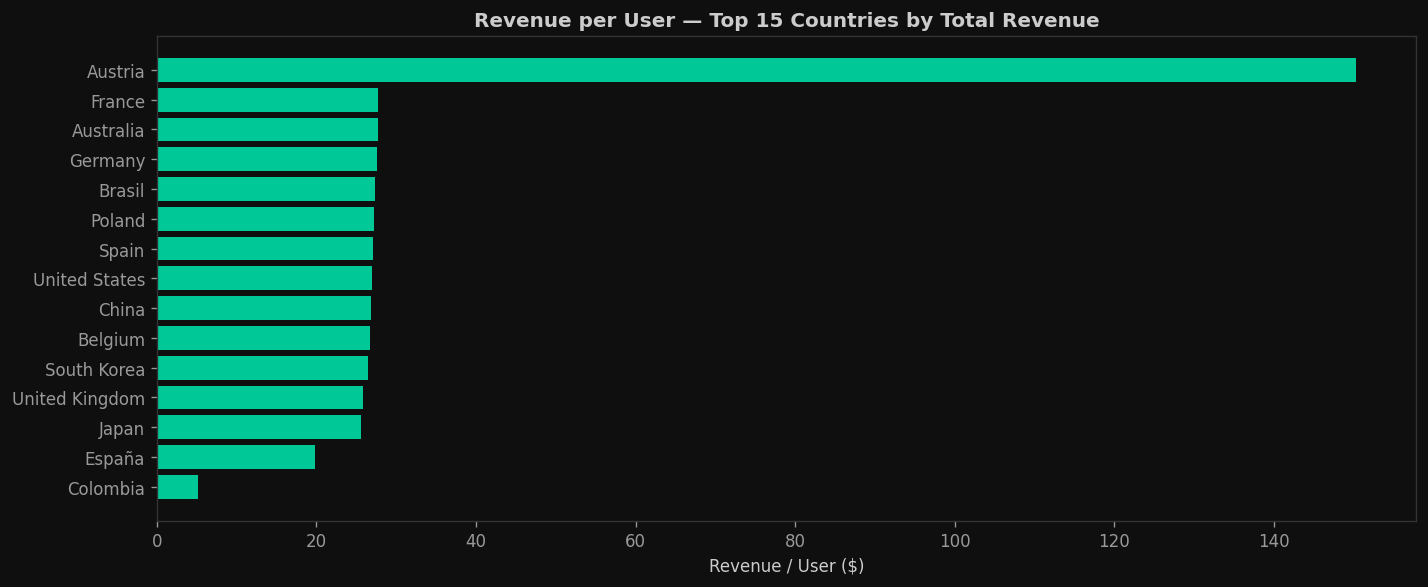

In [13]:
# Top countries by revenue
country_stats = (
    users.groupby("country")
    .agg(users=("user_id", "count"), buyers=("converted", "sum"), revenue=("total_revenue", "sum"))
)
country_stats["conv_%"] = (country_stats["buyers"] / country_stats["users"] * 100).round(1)
country_stats["rev_per_user"] = (country_stats["revenue"] / country_stats["users"]).round(2)
top_countries = country_stats.sort_values("revenue", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 5))
tc = top_countries.sort_values("rev_per_user", ascending=True)
ax.barh(tc.index, tc["rev_per_user"], color=GREEN)
ax.set_xlabel("Revenue / User ($)")
ax.set_title("Revenue per User — Top 15 Countries by Total Revenue", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 7. Cohort Retention

Do users who signed up earlier have higher LTV?

/var/folders/7k/007gkgf90hn56gqpkdw63_v40000gn/T/ipykernel_23496/2212738483.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  users["signup_month"] = users["user_created_at"].dt.to_period("M")


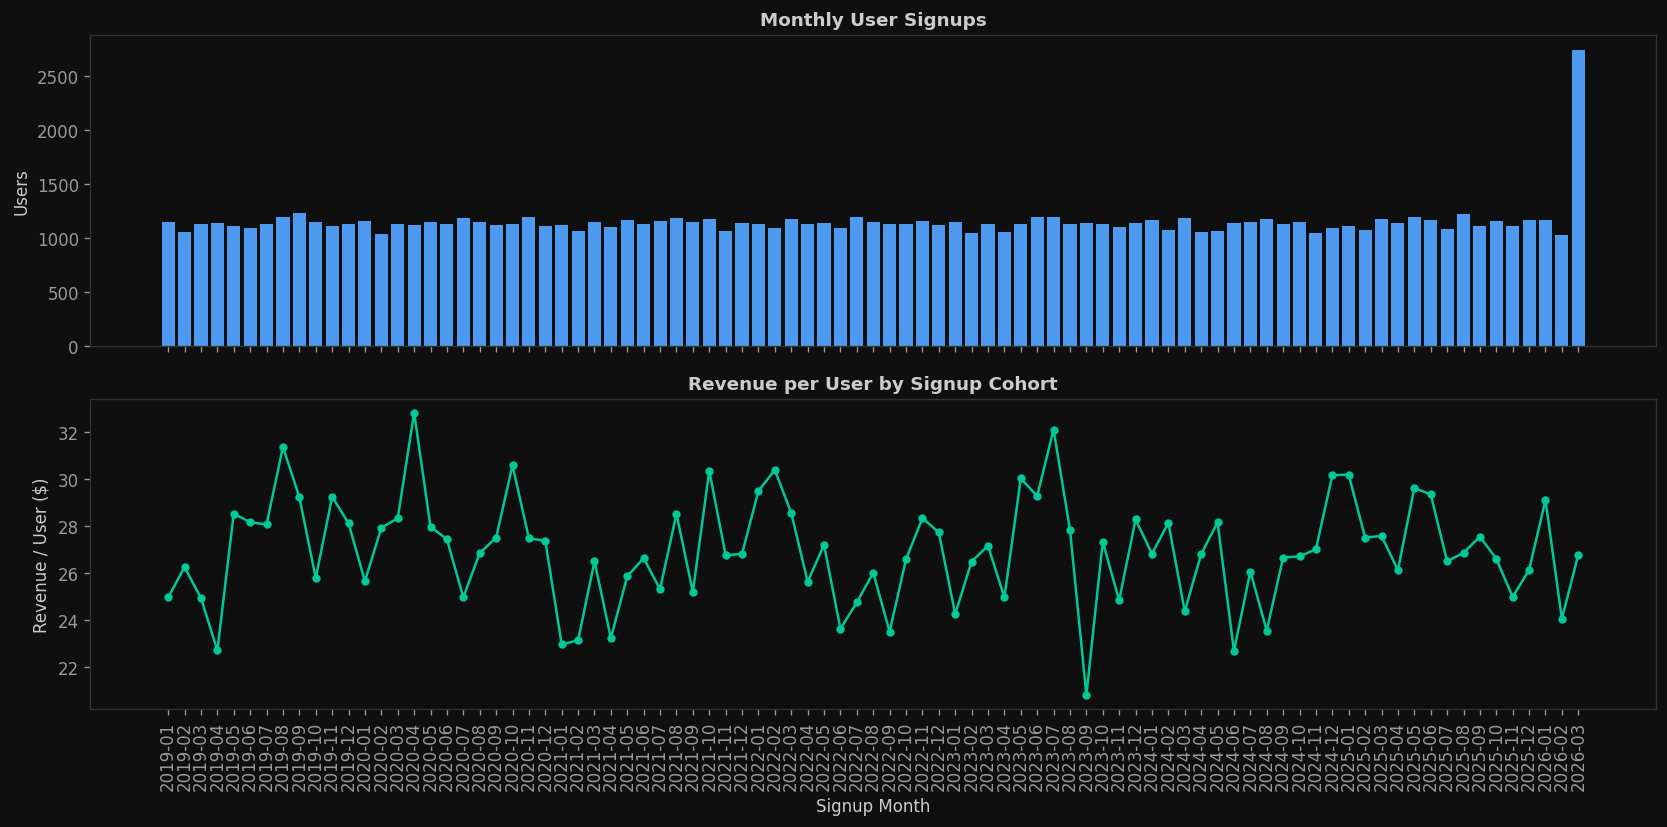

In [14]:
# Monthly cohorts
users["signup_month"] = users["user_created_at"].dt.to_period("M")

cohort = (
    users.groupby("signup_month")
    .agg(
        users=("user_id", "count"),
        buyers=("converted", "sum"),
        revenue=("total_revenue", "sum"),
        avg_orders=("total_orders", "mean"),
    )
)
cohort["conv_%"] = (cohort["buyers"] / cohort["users"] * 100).round(1)
cohort["rev_per_user"] = (cohort["revenue"] / cohort["users"]).round(2)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# User signups over time
axes[0].bar(cohort.index.astype(str), cohort["users"], color=BLUE, width=0.8)
axes[0].set_ylabel("Users")
axes[0].set_title("Monthly User Signups", fontsize=11, fontweight="bold")

# Revenue per user by cohort
axes[1].plot(cohort.index.astype(str), cohort["rev_per_user"],
             color=GREEN, marker="o", markersize=4, lw=1.5)
axes[1].set_ylabel("Revenue / User ($)")
axes[1].set_title("Revenue per User by Signup Cohort", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Signup Month")

for ax in axes:
    ax.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

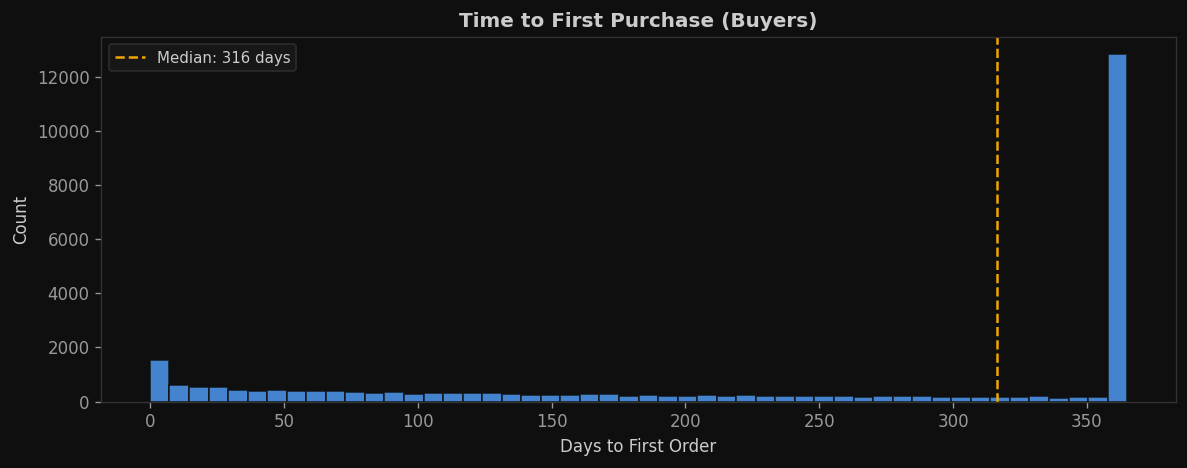

Days to first order: mean=495.5, median=316.5, P90=1268.1


In [15]:
# Days to first order — how fast do users convert?
time_to_convert = buyers["days_to_first_order"].dropna()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(time_to_convert.clip(upper=365), bins=50, color=BLUE, edgecolor="#0f0f0f", alpha=0.85)
ax.axvline(time_to_convert.median(), color=AMBER, ls="--",
           label=f"Median: {time_to_convert.median():.0f} days")
ax.set_xlabel("Days to First Order")
ax.set_ylabel("Count")
ax.set_title("Time to First Purchase (Buyers)", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"Days to first order: mean={time_to_convert.mean():.1f}, "
      f"median={time_to_convert.median():.1f}, P90={time_to_convert.quantile(0.9):.1f}")

---
## 8. Time Trends

Monthly revenue and conversion trends.

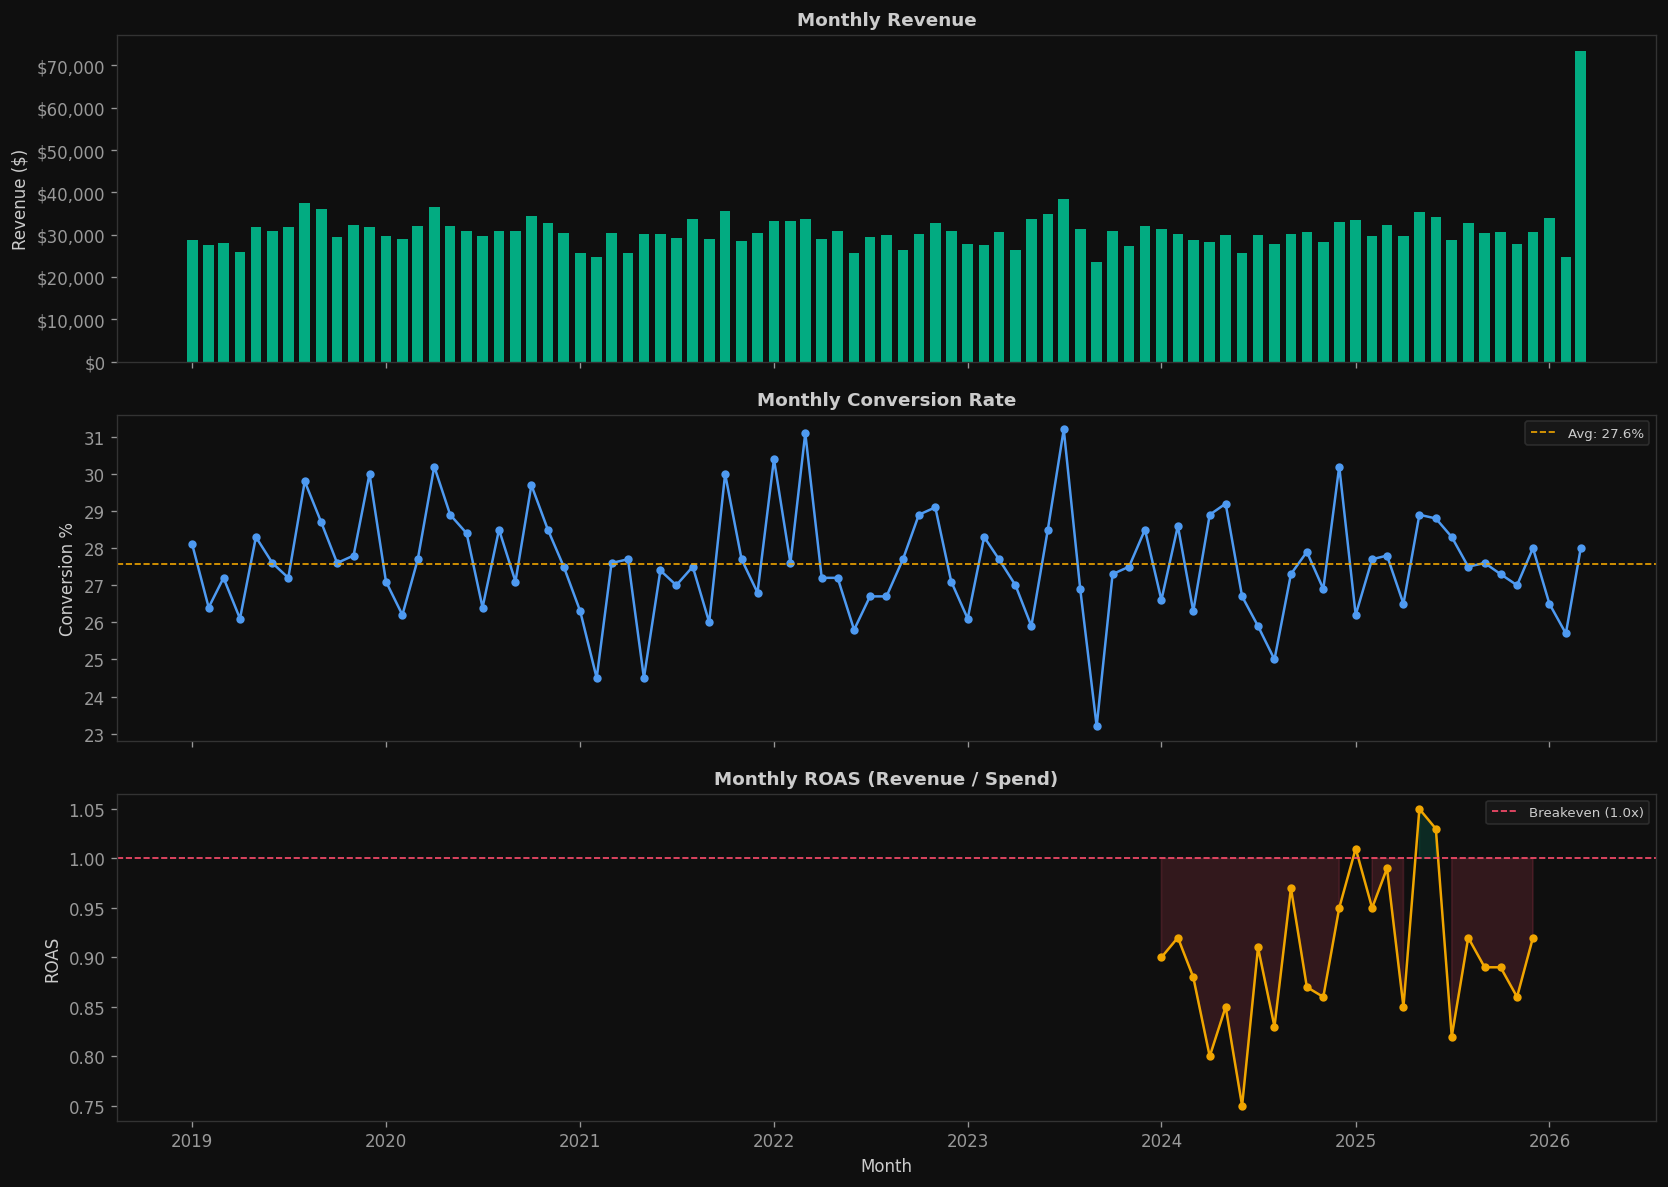

In [16]:
# Monthly trends from mart
mart["month_dt"] = pd.to_datetime(mart["month"], errors="coerce")
monthly_agg = (
    mart.groupby("month_dt")
    .agg(users=("total_users", "sum"), conversions=("conversions", "sum"),
         revenue=("total_revenue", "sum"), spend=("spend", "sum"))
)
monthly_agg = monthly_agg[monthly_agg.index.notna()].sort_index()
monthly_agg["conv_%"] = (monthly_agg["conversions"] / monthly_agg["users"].replace(0, np.nan) * 100).round(1)
monthly_agg["roas"] = (monthly_agg["revenue"] / monthly_agg["spend"].replace(0, np.nan)).round(2)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Revenue
axes[0].bar(monthly_agg.index, monthly_agg["revenue"], color=GREEN, width=20, alpha=0.85)
axes[0].set_ylabel("Revenue ($)")
axes[0].set_title("Monthly Revenue", fontsize=11, fontweight="bold")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# Conversion rate
axes[1].plot(monthly_agg.index, monthly_agg["conv_%"], color=BLUE, marker="o", markersize=4, lw=1.5)
axes[1].axhline(monthly_agg["conv_%"].mean(), color=AMBER, ls="--", lw=1,
                label=f"Avg: {monthly_agg['conv_%'].mean():.1f}%")
axes[1].set_ylabel("Conversion %")
axes[1].set_title("Monthly Conversion Rate", fontsize=11, fontweight="bold")
axes[1].legend(fontsize=8)

# ROAS
axes[2].plot(monthly_agg.index, monthly_agg["roas"], color=AMBER, marker="o", markersize=4, lw=1.5)
axes[2].axhline(1.0, color=RED, ls="--", lw=1, label="Breakeven (1.0x)")
axes[2].fill_between(monthly_agg.index, 1.0, monthly_agg["roas"],
                     where=monthly_agg["roas"] >= 1.0, alpha=0.15, color=GREEN)
axes[2].fill_between(monthly_agg.index, 1.0, monthly_agg["roas"],
                     where=monthly_agg["roas"] < 1.0, alpha=0.15, color=RED)
axes[2].set_ylabel("ROAS")
axes[2].set_xlabel("Month")
axes[2].set_title("Monthly ROAS (Revenue / Spend)", fontsize=11, fontweight="bold")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## 9. Key Findings

In [17]:
print(f"""
KEY FINDINGS — theLook eCommerce
=================================

1. SCALE
   - {total_users:,} users, {total_converted:,} buyers ({conv_rate:.1%} conversion)
   - Total revenue: ${total_revenue:,.0f}

2. REVENUE CONCENTRATION
   - Top {pct_80:.0f}% of buyers generate 80% of revenue
   - Median buyer revenue: ${buyers["total_revenue"].median():,.0f}
   - Mean buyer revenue: ${buyers["total_revenue"].mean():,.0f} (right-skewed)

3. TRAFFIC SOURCES
   - Search dominates volume ({users[users["traffic_source"]=="Search"].shape[0]:,} users)
   - Check ROAS table above for spend efficiency per channel

4. BEHAVIORAL FUNNEL
   - Browsing → Cart and Cart → Purchase are key drop-off points
   - Higher session engagement correlates with higher conversion

5. TIME TO CONVERT
   - Median: {time_to_convert.median():.0f} days to first purchase
   - Targeting early engagement may accelerate conversion

6. DEMOGRAPHICS
   - Gender split is roughly even
   - Age-driven patterns in conversion and revenue per user
""")


KEY FINDINGS — theLook eCommerce

1. SCALE
   - 100,000 users, 27,586 buyers (27.6% conversion)
   - Total revenue: $2,695,974

2. REVENUE CONCENTRATION
   - Top 46% of buyers generate 80% of revenue
   - Median buyer revenue: $64
   - Mean buyer revenue: $98 (right-skewed)

3. TRAFFIC SOURCES
   - Search dominates volume (70,135 users)
   - Check ROAS table above for spend efficiency per channel

4. BEHAVIORAL FUNNEL
   - Browsing → Cart and Cart → Purchase are key drop-off points
   - Higher session engagement correlates with higher conversion

5. TIME TO CONVERT
   - Median: 316 days to first purchase
   - Targeting early engagement may accelerate conversion

6. DEMOGRAPHICS
   - Gender split is roughly even
   - Age-driven patterns in conversion and revenue per user

